#### Importing necessary libraries


In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [151]:
df = pd.read_csv('../data/coffe_quality.csv')

In [152]:
df_clean = df.copy()

In [153]:
columns_to_drop = [
    "Unnamed: 0", "ID", "Farm Name", "Lot Number", "Mill",
    "ICO Number", "Company", "Producer", "In-Country Partner",
    "Owner", "Grading Date", "Expiration", "Certification Body",
    "Certification Address", "Certification Contact","Country of Origin","Variety","Processing Method","Color"
]
df_clean = df_clean.drop(columns= columns_to_drop)

In [154]:
df_clean = df_clean.drop(columns = ["Region", "Altitude"])

In [155]:
df_clean["Bag Weight"] = df_clean["Bag Weight"].str.replace(" kg", "").astype(float)

In [156]:
df_clean["Harvest Year"] = df_clean["Harvest Year"].str.split("/").str[0]
df_clean["Harvest Year"] = pd.to_numeric(df_clean["Harvest Year"], errors="coerce")

In [60]:
thereshold = 10
counts = df_clean["Color"].value_counts()#df_clean["Variety"].value_counts()


In [61]:
df_clean["Color"] = df_clean["Color"].apply(
    lambda x: x if counts.get(x, 0) >= thereshold else "Other"
)

In [62]:
df_clean["Color"].value_counts()

Color
green           101
greenish         36
Other            27
bluish-green     21
blue-green       12
yellow-green     10
Name: count, dtype: int64

In [63]:
df_clean = pd.get_dummies(
    df_clean, columns=[
        "Country of Origin",
        "Variety",
        "Processing Method",
        "Color"
    ],
    drop_first= True
)

In [64]:
df_clean.dtypes

Number of Bags                                      int64
Bag Weight                                        float64
Harvest Year                                        int64
Status                                                str
Aroma                                             float64
Flavor                                            float64
Aftertaste                                        float64
Acidity                                           float64
Body                                              float64
Balance                                           float64
Uniformity                                        float64
Clean Cup                                         float64
Sweetness                                         float64
Overall                                           float64
Defects                                           float64
Total Cup Points                                  float64
Moisture Percentage                               float64
Category One D

In [157]:
df_clean = df_clean.drop(columns="Status")

In [66]:
import seaborn as sns


In [162]:
corr = df_clean.corr(numeric_only=True)

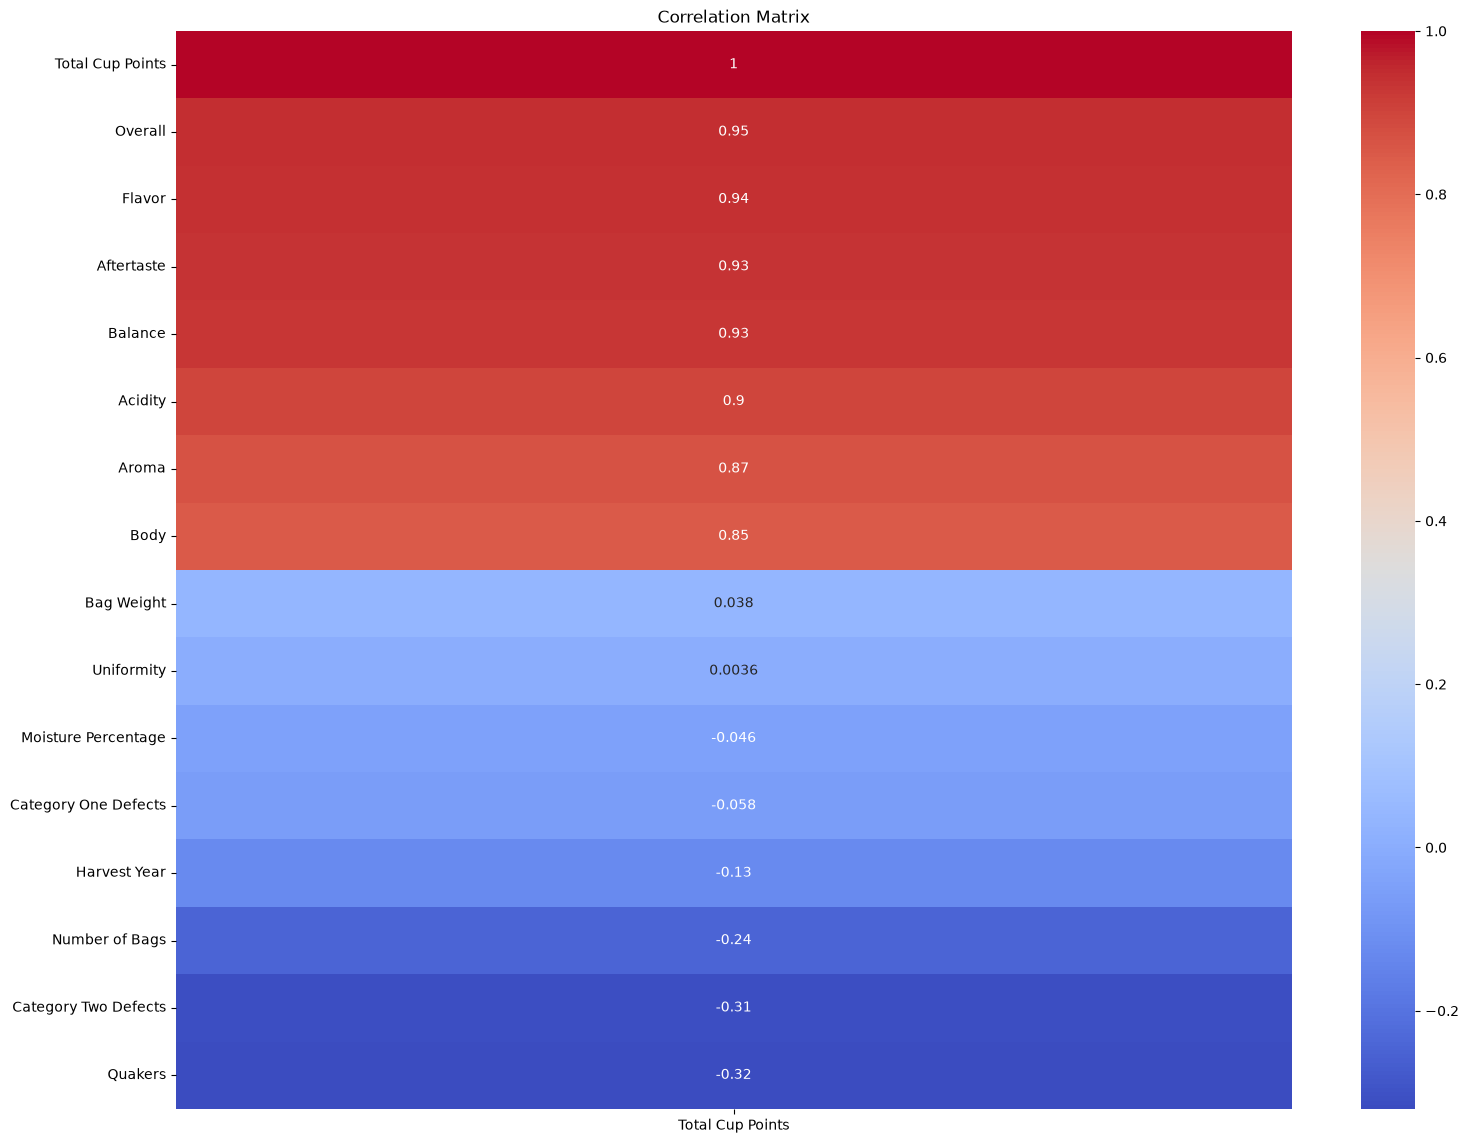

In [163]:
plt.figure(figsize=(18,14))
sns.heatmap(
    corr[["Total Cup Points"]].sort_values(
            by = "Total Cup Points",
            ascending=False
    ),
    annot=True,
    cmap="coolwarm"
    )
plt.title("Correlation Matrix")
plt.show()

In [160]:
df_clean = df_clean.drop(columns=["Sweetness", "Defects", "Clean Cup"])

In [173]:
df_clean = df_clean.drop(columns=["Uniformity", "Bag Weight", "Moisture Percentage", "Category One Defects"])

In [164]:
df_clean.shape

(207, 16)

In [174]:
X = df_clean.drop(columns=["Total Cup Points"])
y = df_clean["Total Cup Points"]

In [175]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [182]:
from sklearn.preprocessing import StandardScaler
x_scaler = StandardScaler()
y_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1,1))

In [183]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import Input
from tensorflow.keras.optimizers import Adam


In [184]:
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
  
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1)
]
)

In [185]:
model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss = "mse",
    metrics=["mae"]
)

In [186]:
history = model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=500,
    validation_split=0.2,
    verbose =1
)

Epoch 1/500


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 1.0950 - mae: 0.8154 - val_loss: 0.8685 - val_mae: 0.7345
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.8726 - mae: 0.7205 - val_loss: 0.6598 - val_mae: 0.6343
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.7210 - mae: 0.6402 - val_loss: 0.5133 - val_mae: 0.5468
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6076 - mae: 0.5700 - val_loss: 0.4080 - val_mae: 0.4696
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5208 - mae: 0.5109 - val_loss: 0.3224 - val_mae: 0.4014
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4504 - mae: 0.4610 - val_loss: 0.2545 - val_mae: 0.3548
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3906 - mae: 0.4235 - val_loss: 0.2011 - val_mae: 0.3176
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3349 - mae: 0.3898 - val_loss: 0.1563 - val_mae: 0.2850
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2826 - mae: 0.3538 - val

In [187]:
loss, mae = model.evaluate(X_test_scaled, y_test_scaled)
print(f"loss:{loss:.4f}")
print(f"MAE:{mae:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0155 - mae: 0.0893
loss:0.0155
MAE:0.0893


In [131]:
y.describe()

count    207.000000
mean      83.706570
std        1.730417
min       78.000000
25%       82.580000
50%       83.750000
75%       84.830000
max       89.330000
Name: Total Cup Points, dtype: float64

In [101]:
X_train[:5]

array([[ 1.03330239, -0.1153987 ,  0.81778585, -0.21471912,  0.27396903,
         0.19641964,  0.48837045,  0.43166047,  0.0777171 ,  0.10512681,
        -0.05082392,  0.25060619, -0.21271781,  0.18232903, -0.04989565,
        -0.33891719, -0.1767767 , -0.1767767 , -0.24019223,  2.85773803,
        -0.24019223, -0.13608276, -0.07808688, -0.13608276, -0.07808688,
        -0.11076976, -0.07808688, -0.15762208, -0.11076976, -0.15762208,
        -0.64051262, -0.1767767 , -0.26726124, -0.11076976, -0.15762208,
        -0.13608276, -0.24019223, -0.22573306,  2.54950976, -0.39223227,
        -0.77584905, -0.39223227, -0.21048467, -0.28005602, -0.36074504,
         0.8372759 , -0.24019223, -0.31622777,  1.05611771, -0.49051147,
        -0.22573306],
       [ 8.00438214, -0.10109236,  0.81778585, -1.99148215, -2.0752615 ,
        -2.48350651, -1.98643372, -0.95992702, -1.83621144,  0.10512681,
        -1.93926251,  0.64630016, -0.21271781, -0.44442701,  0.66599844,
        -0.33891719, -0.17677

In [102]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,629 (25.90 KB)

 Trainable params: 2,209 (8.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,420 (17.27 KB)

In [143]:
pred = model.predict(X_test)
print(pred[:10].flatten())
print(y_test[:10].values)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
[-33.906265 -29.214884 -29.02511  -29.255838 -35.62213  -33.78144
 -34.04146  -29.088167 -29.843798 -29.898073]
[82.5  86.08 84.42 83.92 82.33 86.5  83.83 83.17 85.92 82.75]


In [190]:
pred_scaled = model.predict(X_test_scaled)

pred = y_scaler.inverse_transform(pred_scaled).flatten()

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, pred)
print("mae= ", mae)

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7f33e9ff65c0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
mae=  0.15687996273949048


In [189]:
pred = pred.flatten()
pred_real = y_scaler.inverse_transform(pred_scaled).flatten()
for real, estimado in zip(y_test[:10], pred_real[:10]):
    print(f"Real: {real:.2f} | prediccion: {estimado:.2f}")

Real: 82.50 | prediccion: 82.56
Real: 86.08 | prediccion: 86.34
Real: 84.42 | prediccion: 84.64
Real: 83.92 | prediccion: 84.03
Real: 82.33 | prediccion: 82.79
Real: 86.50 | prediccion: 86.35
Real: 83.83 | prediccion: 84.39
Real: 83.17 | prediccion: 84.40
Real: 85.92 | prediccion: 85.61
Real: 82.75 | prediccion: 82.93
